<a href="https://colab.research.google.com/github/bisu617/ai-misinformation-detection/blob/main/model-stage2/bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Mount Drive + Install Libraries
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
# CELL 2: Check GPU
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: Tesla T4


In [ ]:
# CELL 3: Load Dataset
import pandas as pd

# CHANGE THIS to your actual dataset path in Drive
DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/merged_cleaned_misinfo.csv'
df = pd.read_csv(DATASET_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nLabel distribution:')
print(df['final_int'].value_counts())
print('\nSample:')
print(df[['clean_text', 'final_int']].head(3))

Shape: (99144, 14)
Columns: ['id', 'title', 'text', 'text_input', 'source_label', 'misinfo_label', 'final_label', 'final_int', 'model', 'watermarked', 'topic', 'split', 'generator_model', 'clean_text']

Label distribution:
final_int
0.0    39452
1.0     9692
Name: count, dtype: int64

Sample:
                                          clean_text  final_int
0  census data released with assistance from imf ...        0.0
1  national education association has awarded 120...        0.0
2  overview fda has issued updated guidelines req...        0.0


/tmp/ipykernel_1608/4111373176.py:6: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


In [ ]:
# CELL 4: Prepare Train / Val / Test Split
from sklearn.model_selection import train_test_split

# Use clean_text as input and final_int as label
df = df[['clean_text', 'final_int']].copy()
df = df.rename(columns={'clean_text': 'text', 'final_int': 'label'})

# Clean up
df['text']  = df['text'].astype(str).str.strip()
# Drop rows where 'label' is NaN before converting to int
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
df = df[df['text'].str.len() >= 30]
df = df[df['label'].isin([0, 1])]
df = df.drop_duplicates(subset=['text'])
df = df.reset_index(drop=True)

print('Cleaned shape:', df.shape)
print('Label distribution:')
print(df['label'].value_counts())

Cleaned shape: (48766, 2)
Label distribution:
label
0    39217
1     9549
Name: count, dtype: int64


In [ ]:
# Split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'\nTrain: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')


Train: (39012, 2)
Val:   (4877, 2)
Test:  (4877, 2)


In [ ]:
# CELL 5: Convert to HuggingFace Dataset + Tokenize
from datasets import Dataset
from transformers import AutoTokenizer

model_name = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128, padding='max_length')

train_tok = train_ds.map(tokenize, batched=True, remove_columns=['text'])
val_tok   = val_ds.map(tokenize,   batched=True, remove_columns=['text'])
test_tok  = test_ds.map(tokenize,  batched=True, remove_columns=['text'])

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenization done!')
print(train_tok)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/39012 [00:00<?, ? examples/s]

Map:   0%|          | 0/4877 [00:00<?, ? examples/s]

Map:   0%|          | 0/4877 [00:00<?, ? examples/s]

Tokenization done!
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 39012
})


In [ ]:
# CELL 6: Load BERT Model + Metrics
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

id2label = {0: 'factual',        1: 'misinformation'}
label2id = {'factual': 0, 'misinformation': 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds,  references=labels, average='binary')['f1']
    }

print('Model loaded!')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:
# CELL 7: Training Arguments + Trainer
args = TrainingArguments(
    output_dir='bert_stage2',
    eval_strategy='steps',
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
torch.cuda.empty_cache()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [ ]:

# CELL 8: Train
# Watch Train Loss vs Val Loss in the table below
train_result = trainer.train()
print('\nTraining complete!')
print(f"Total train time : {train_result.metrics['train_runtime']:.1f}s")
print(f"Train samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.082232,0.075490,0.974780,0.931400
1000,0.057896,0.053152,0.979701,0.945334
1500,0.055624,0.055696,0.979701,0.945334
2000,0.060901,0.052940,0.979701,0.945334
2500,0.061348,0.054733,0.979701,0.945334
3000,0.079787,0.056707,0.979701,0.945334
3500,0.056712,0.056105,0.979701,0.945334
4000,0.049113,0.055353,0.979701,0.945334
4500,0.062349,0.106683,0.974575,0.932755
5000,0.053207,0.061236,0.979701,0.945334


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
Total train time : 3506.9s
Train samples/sec: 33.4


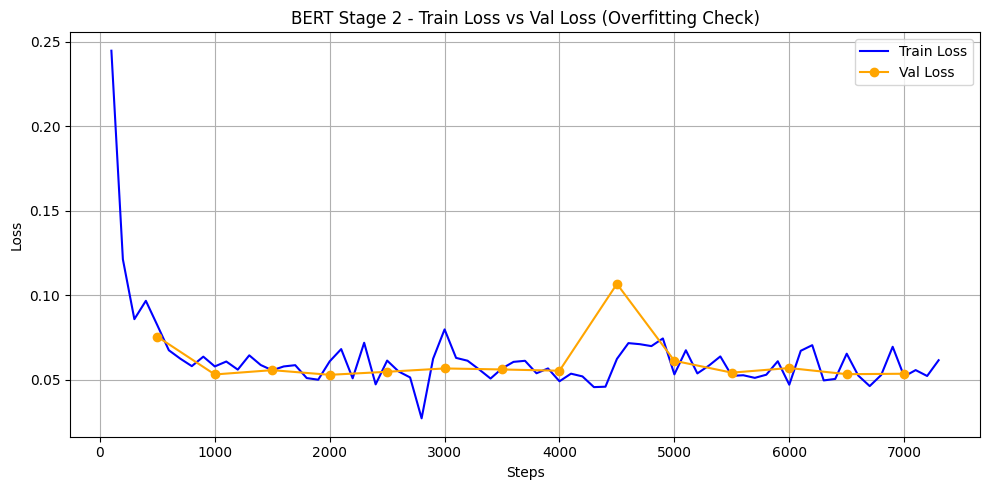

Overfitting plot saved!


In [ ]:

# CELL 9: Overfitting Plot

import matplotlib.pyplot as plt
import os # Import the os module for directory operations

logs = trainer.state.log_history

train_steps  = [x['step'] for x in logs if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in logs if 'loss' in x and 'eval_loss' not in x]
val_steps    = [x['step'] for x in logs if 'eval_loss' in x]
val_losses   = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps,   val_losses,   label='Val Loss',   color='orange', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('BERT Stage 2 - Train Loss vs Val Loss (Overfitting Check)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/content/drive/MyDrive/AI_Humanizer/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'overfitting_stage2.png'), dpi=150)
plt.show()
print('Overfitting plot saved!')


In [ ]:

# CELL 10: Final Test Evaluation
test_results = trainer.evaluate(test_tok)
print('\n========== FINAL TEST RESULTS (STAGE 2) ==========')
print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")
print(f"Eval Loss: {test_results['eval_loss']:.4f}")
print('===================================================')



========== FINAL TEST RESULTS (STAGE 2) ==========
Accuracy : 0.9777
F1 Score : 0.9395
Eval Loss: 0.0578



=== Classification Report ===
                precision    recall  f1-score   support

       Factual       0.97      1.00      0.99      3922
Misinformation       1.00      0.89      0.94       955

      accuracy                           0.98      4877
     macro avg       0.99      0.94      0.96      4877
  weighted avg       0.98      0.98      0.98      4877



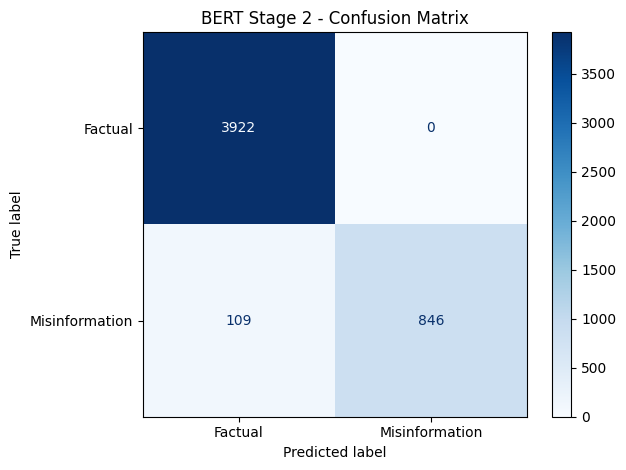

Confusion matrix saved!


In [ ]:
# CELL 11: Confusion Matrix + Classification Report
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['Factual', 'Misinformation']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Misinformation'])
disp.plot(cmap='Blues')
plt.title('BERT Stage 2 - Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Humanizer/confusion_matrix_stage2.png', dpi=150)
plt.show()
print('Confusion matrix saved!')

In [ ]:
# CELL 12: Save Model to Drive
save_path = '/content/drive/MyDrive/AI_Humanizer/bert_stage2_model'
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print('Stage 2 model saved to:', save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 2 model saved to: /content/drive/MyDrive/AI_Humanizer/bert_stage2_model


In [ ]:

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

#Load Stage 2 model only
STAGE2_PATH = '/content/drive/MyDrive/AI_Humanizer/bert_stage2_model'
stage2_tokenizer = AutoTokenizer.from_pretrained(STAGE2_PATH)
stage2_model     = AutoModelForSequenceClassification.from_pretrained(STAGE2_PATH)
stage2_model.eval()

print(f"Stage 2 labels: {stage2_model.config.id2label}")
def run_stage2(text):
    print(f"\n{'='*60}")
    print(f"Input: {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"{'='*60}")
    inputs = stage2_tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    )

    with torch.no_grad():
        out = stage2_model(**inputs)
    probs  = torch.softmax(out.logits, dim=-1)
    pred   = torch.argmax(probs, dim=-1).item()
    conf   = probs[0][pred].item()
    label  = stage2_model.config.id2label[pred].upper()
    print(f"Stage 2  →  {label}  (Confidence: {conf * 100:.2f}%)")
    if label == 'MISINFO':

        print("Final    →  MISINFORMATION DETECTED")

    else:
        print("Final    → NOT misinformation")

# Test texts
test_texts = [
    "honestly i dont even know what to do lol my laptop keeps crashing",
    "Artificial intelligence refers to the simulation of human intelligence by machines.",
    "Scientists have confirmed that drinking coffee every morning increases lifespan by 20 years according to a new study.",
    "The mitochondria generates most of the cell's supply of adenosine triphosphate used as chemical energy.",

]

for text in test_texts:
    run_stage2(text)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Stage 2 labels: {0: 'factual', 1: 'misinformation'}

Input: honestly i dont even know what to do lol my laptop keeps crashing
Stage 2  →  FACTUAL  (Confidence: 81.73%)
Final    → NOT misinformation

Input: Artificial intelligence refers to the simulation of human intelligence by machin...
Stage 2  →  FACTUAL  (Confidence: 86.31%)
Final    → NOT misinformation

Input: Scientists have confirmed that drinking coffee every morning increases lifespan ...
Stage 2  →  FACTUAL  (Confidence: 99.98%)
Final    → NOT misinformation

Input: The mitochondria generates most of the cell's supply of adenosine triphosphate u...
Stage 2  →  FACTUAL  (Confidence: 92.32%)
Final    → NOT misinformation
